<a href="https://colab.research.google.com/github/DmitriyKolesnikM8O/MLLabs/blob/lab1/ML1LAb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Взлетаем**

**Общая информация о датасете:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

**Верхушка этого айсберга:**

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


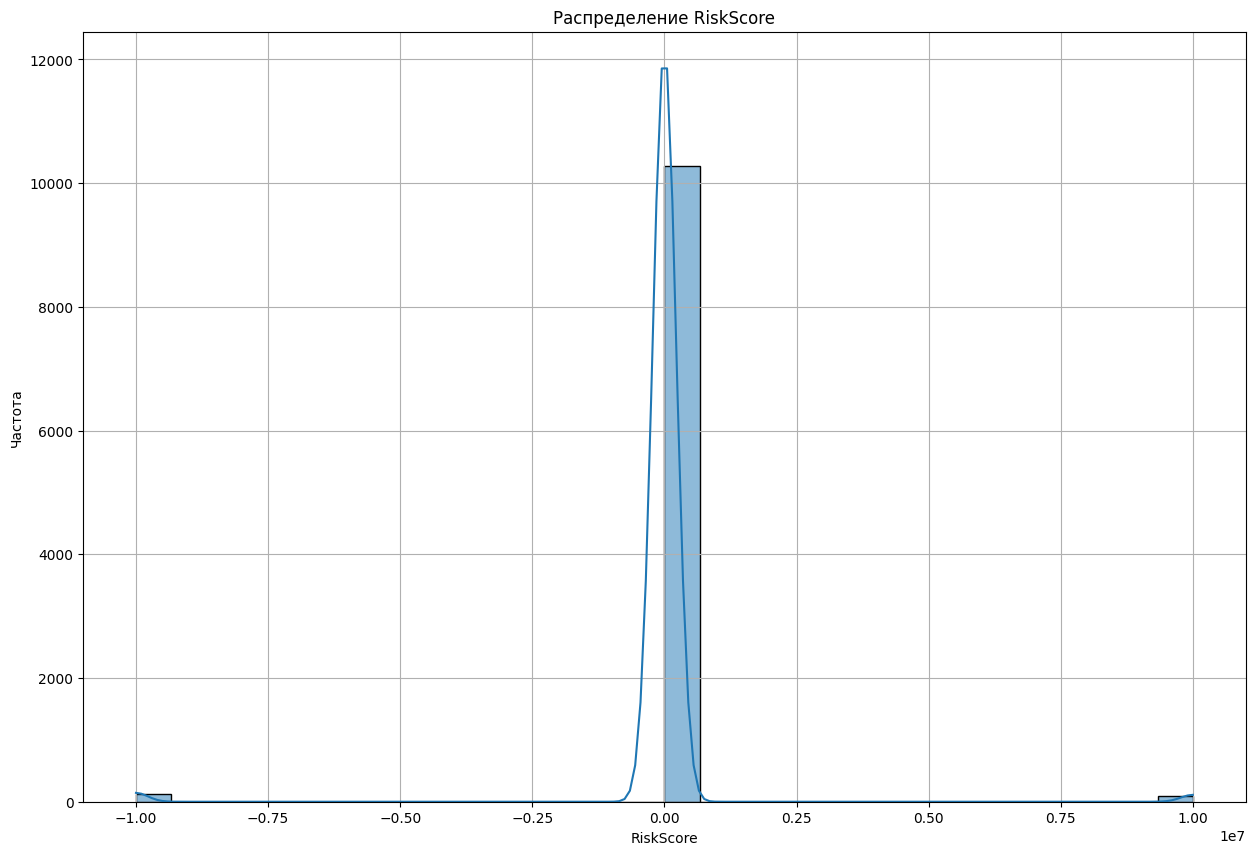

**Вывод:** Небольшие выбросы в начале и конце, БОЛЬШИЕ около 0 и дальше все значения близки к 0. Как будто не очень, эти штуки будут вредить модельке

,RiskScore
count,1.048700e+04
mean,-2.569878e+04
std,1.431675e+06
min,-9.999999e+06
25%,3.256475e+01
50%,4.411876e+01
75%,6.535690e+01
max,1.000000e+07


**Вывод:** Как будто это подтверждает идею о выбросах. Половина данных между 32 и 66, но есть экстремальные значения + среднее смещено

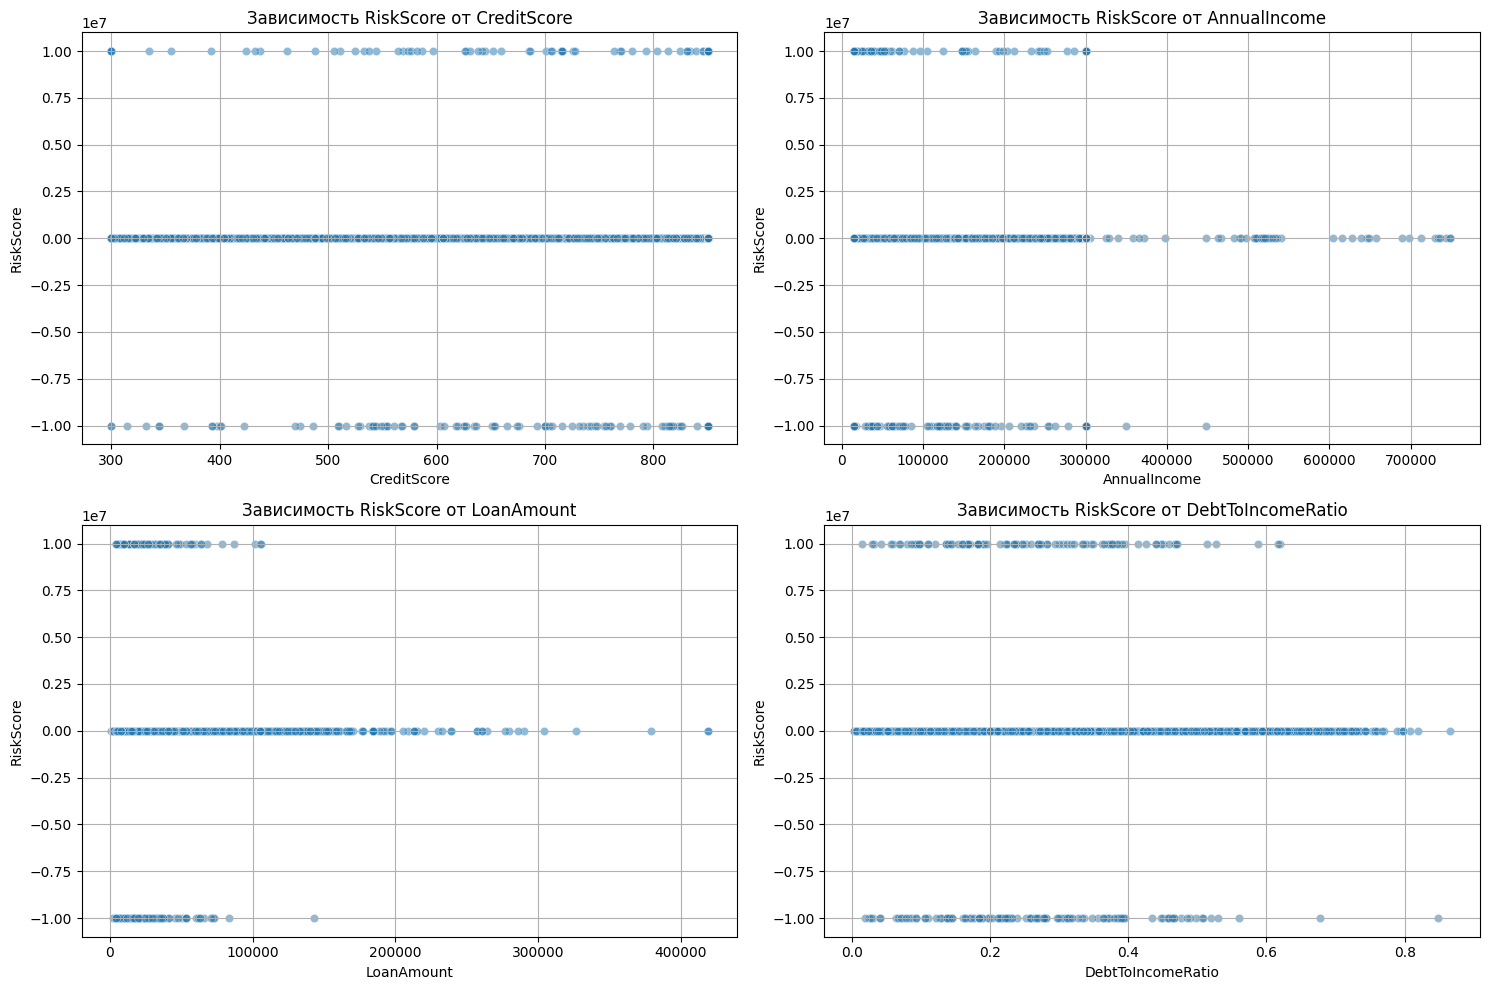

**Вывод:** Четкие горизонтальные линии. Как будто следствия этих выбросов. Реальную зависимость увидеть тяжко

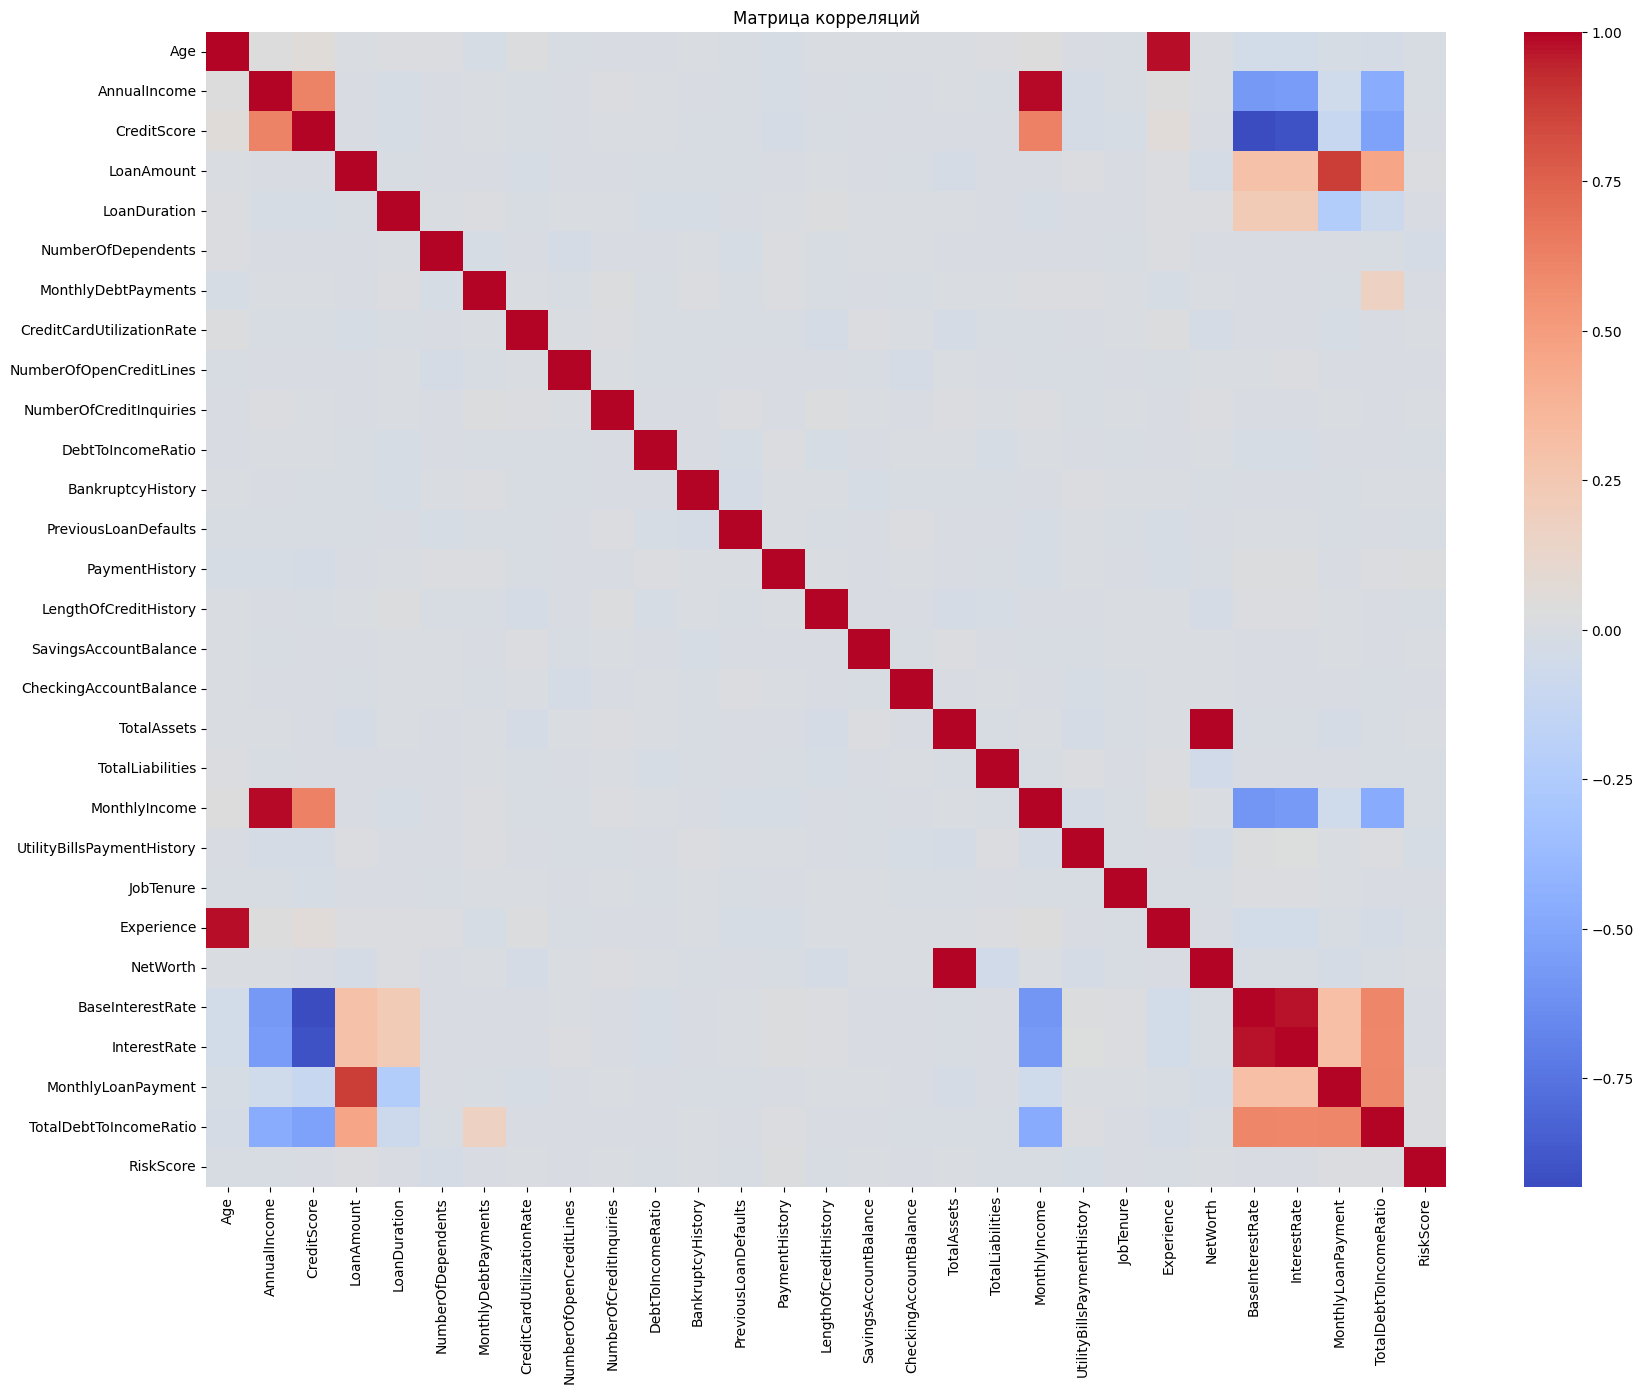

**Топ-10 самых коррелирующих с RiskScore признаков:**

,RiskScore
RiskScore,1.000000
PaymentHistory,0.019144
TotalDebtToIncomeRatio,0.013879
MonthlyLoanPayment,0.012366
LoanAmount,0.011771
NumberOfCreditInquiries,0.011055
NetWorth,0.008804
TotalAssets,0.008092
SavingsAccountBalance,0.007611
CreditCardUtilizationRate,0.005501


**Вывод:** Тупые выбросы... Ну по топ-10 даже видно, что линейные зависимости почти не обнаруживаются. Лучшая корреляция у PaymentHistory, но и то мелкая

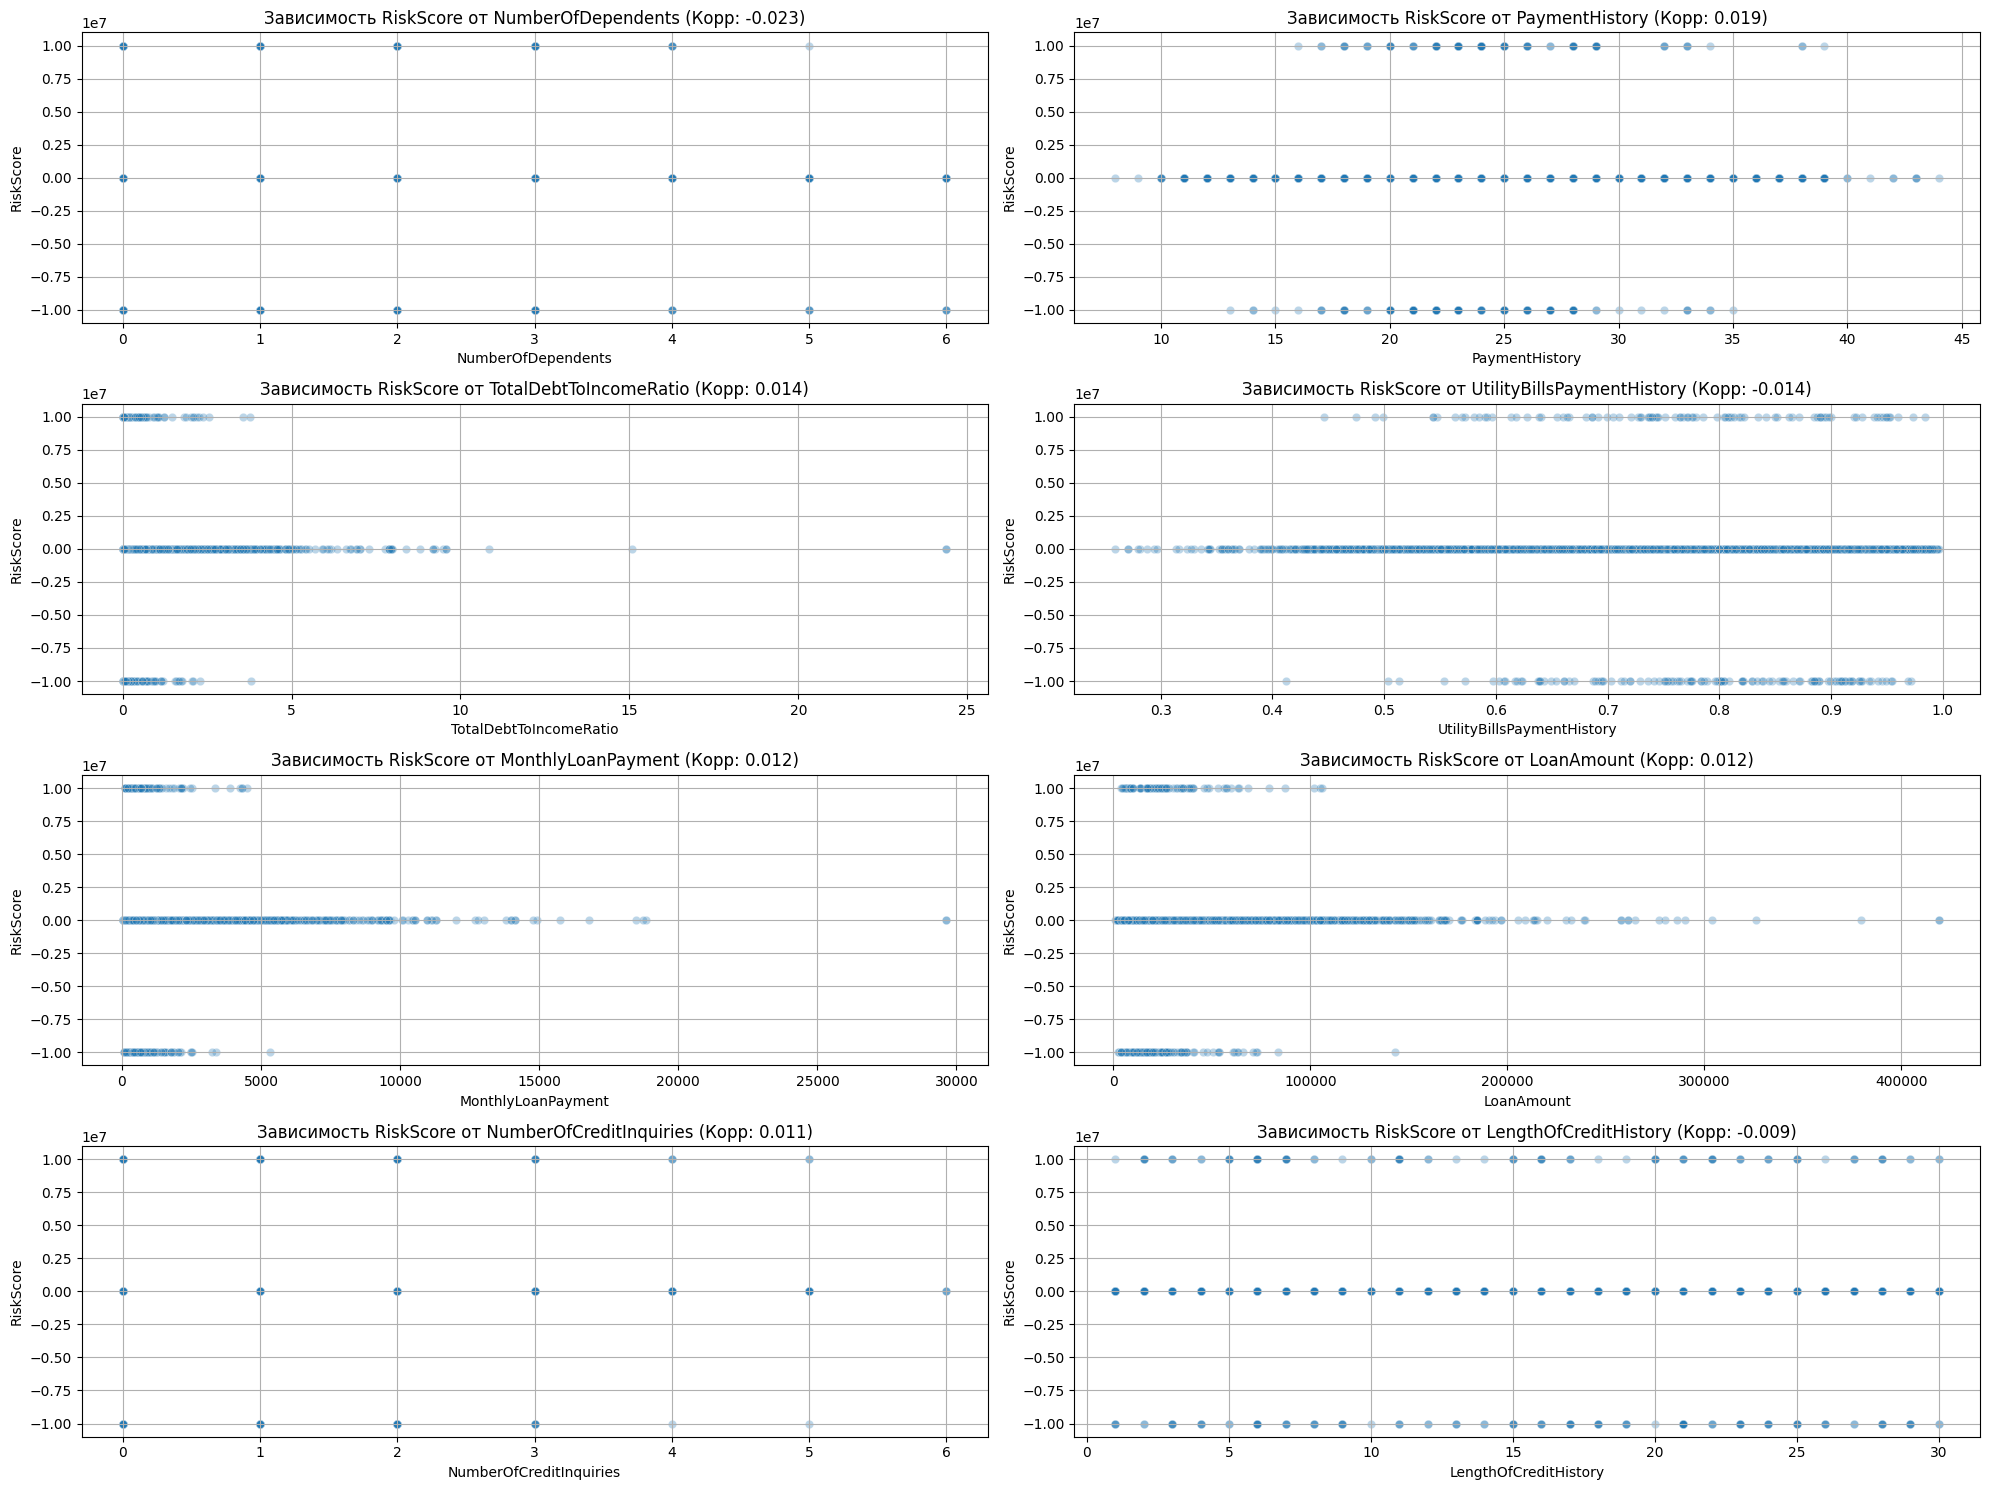

**Вывод:** Результат ожидаемый...

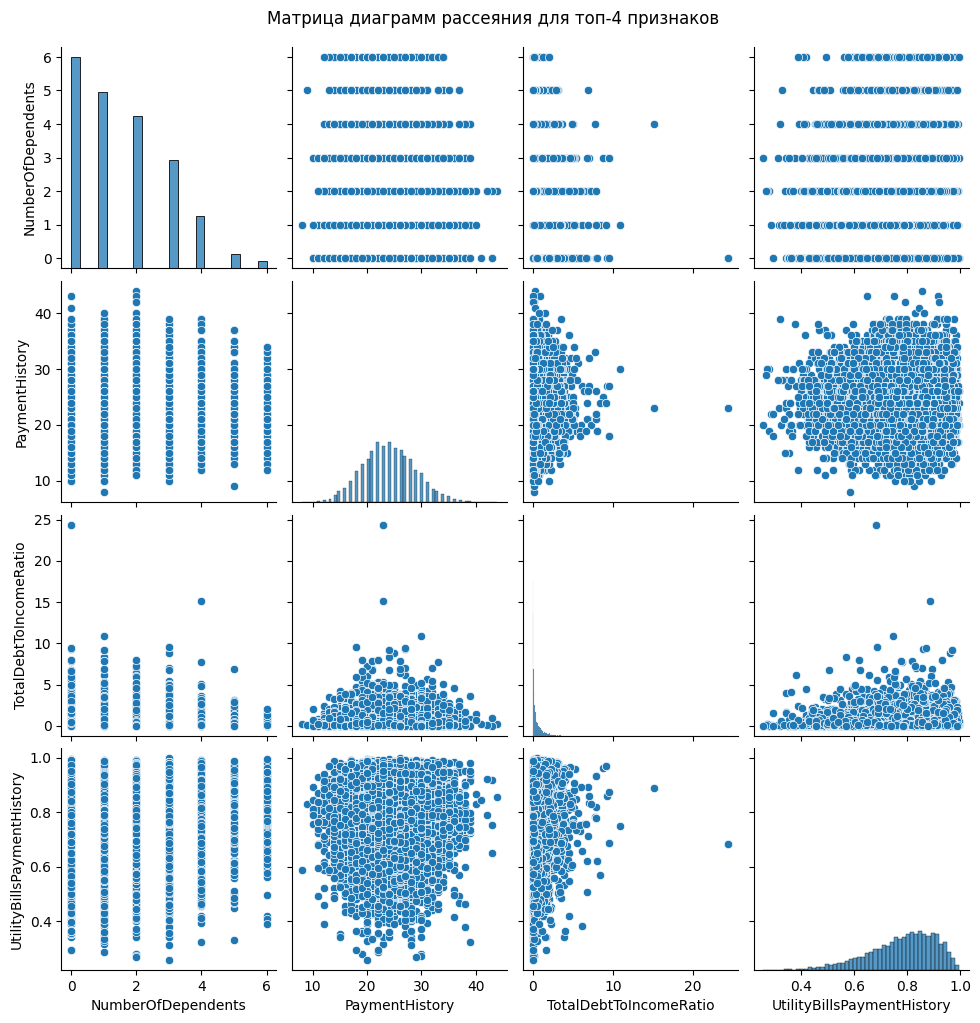

**Вывод:** Вроде они не коррелируют особо, значит мультиколлинеарность не беда.

*Основная беда - экстремальные выбросы. Но мультиколлинеарности нет. Нужно очистить данные.*

## Очистка данных от выбросов

Исходное количество строк: `11017`.

Количество строк после очистки: `10272`.

**Удалено `745` строк с выбросами.**

## Повторный взгляд на данные после очистки

**1. Распределение `RiskScore` (очищенные данные):**

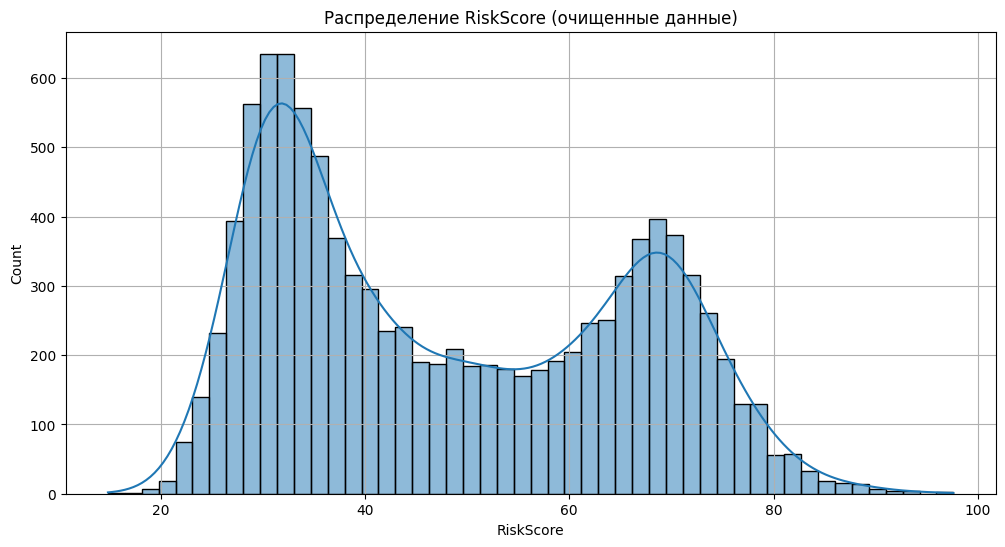

**Вывод:** Теперь распределение выглядит как биномиальное: 1 вершина в районе возле 30, 2 - возле 70. МБ существует 2 скрытые категории клиентов, дальше разберемся

**2. Матрица корреляций (очищенные данные):**

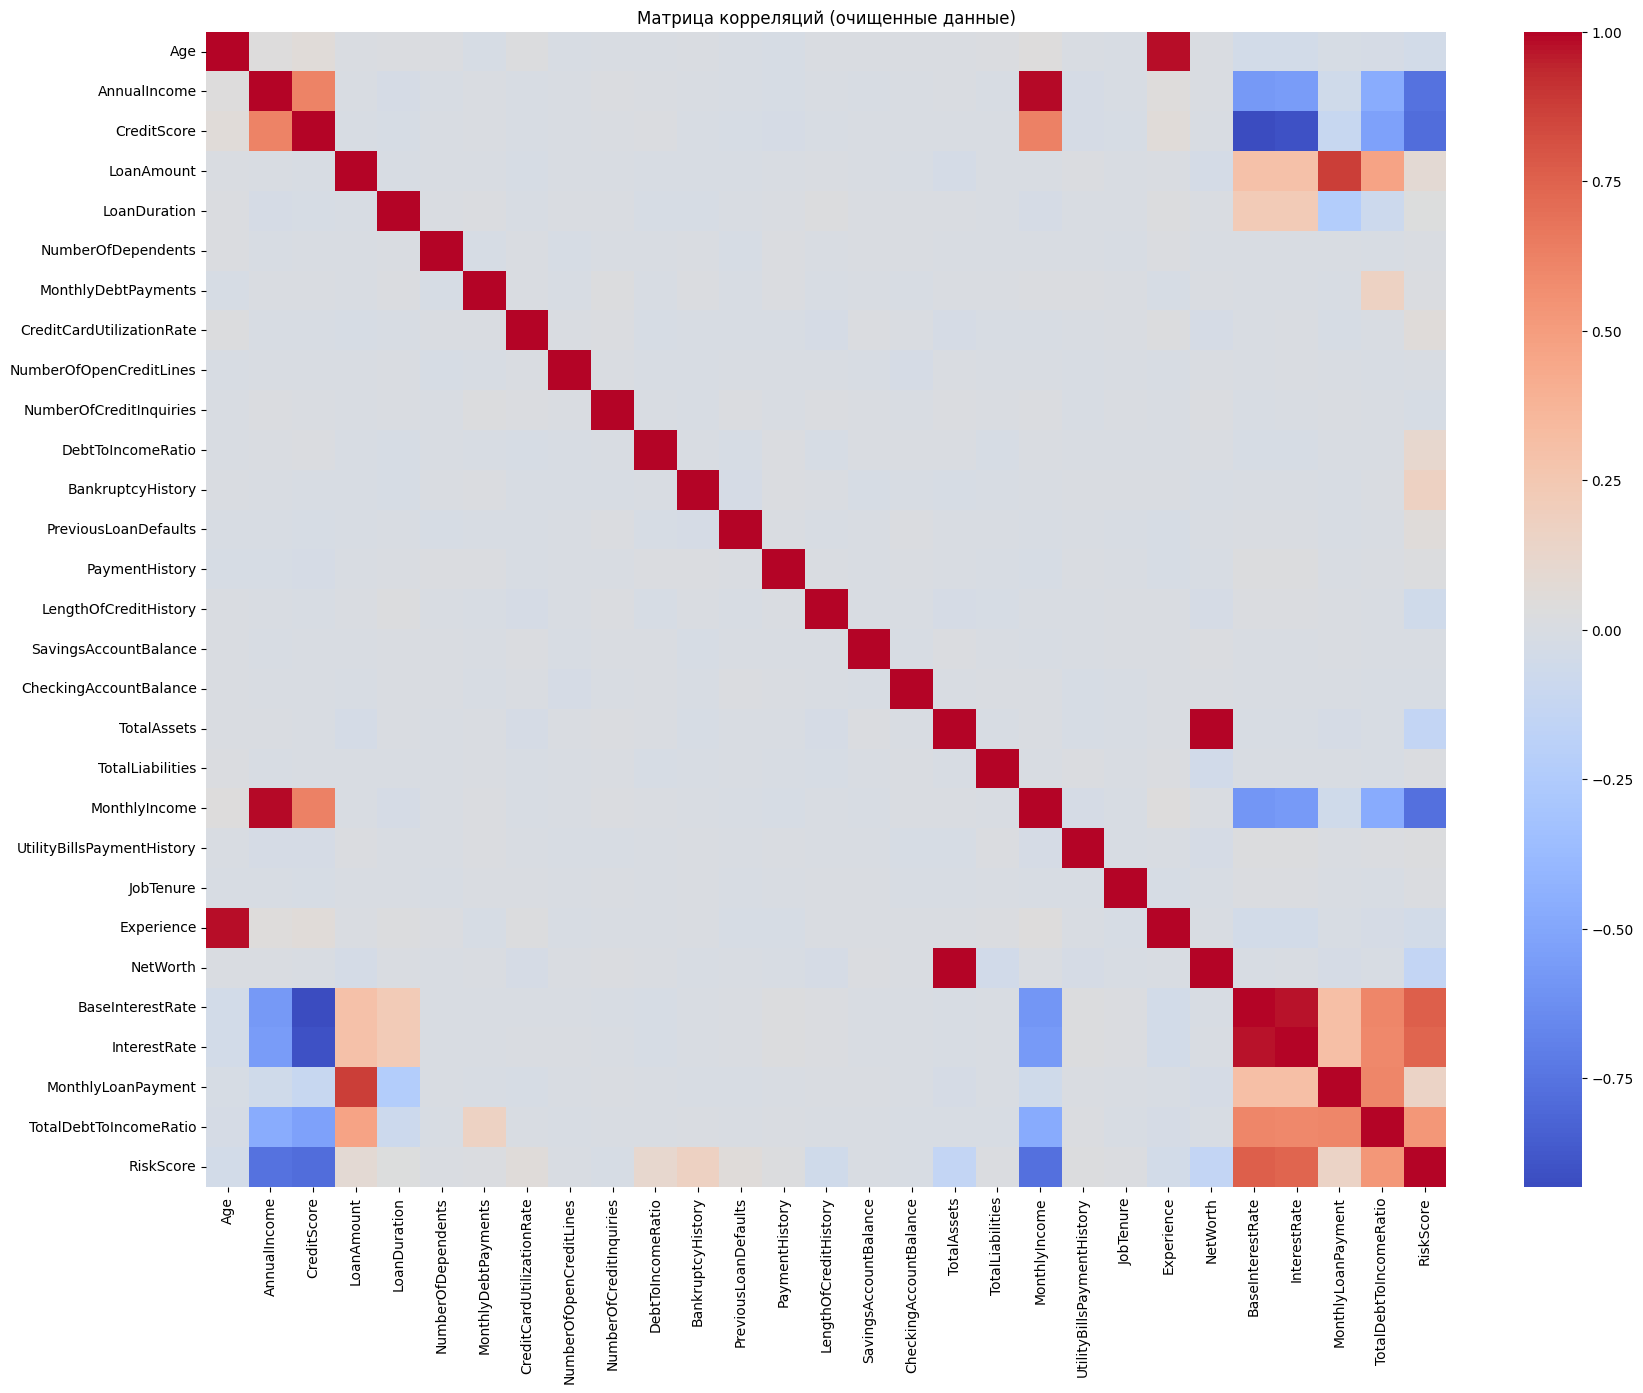

**Вывод:** Пятен стало больше (GOOD). Наиболее заметна сильная отрицательная корреляция RiskScore с CreditScore и MonthlyIncome (синие квадраты), и сильная положительная — с InterestRate и BaseInterestRate (красные квадраты).

**3. Зависимость Топ-8 признаков от `RiskScore` (очищенные данные):**

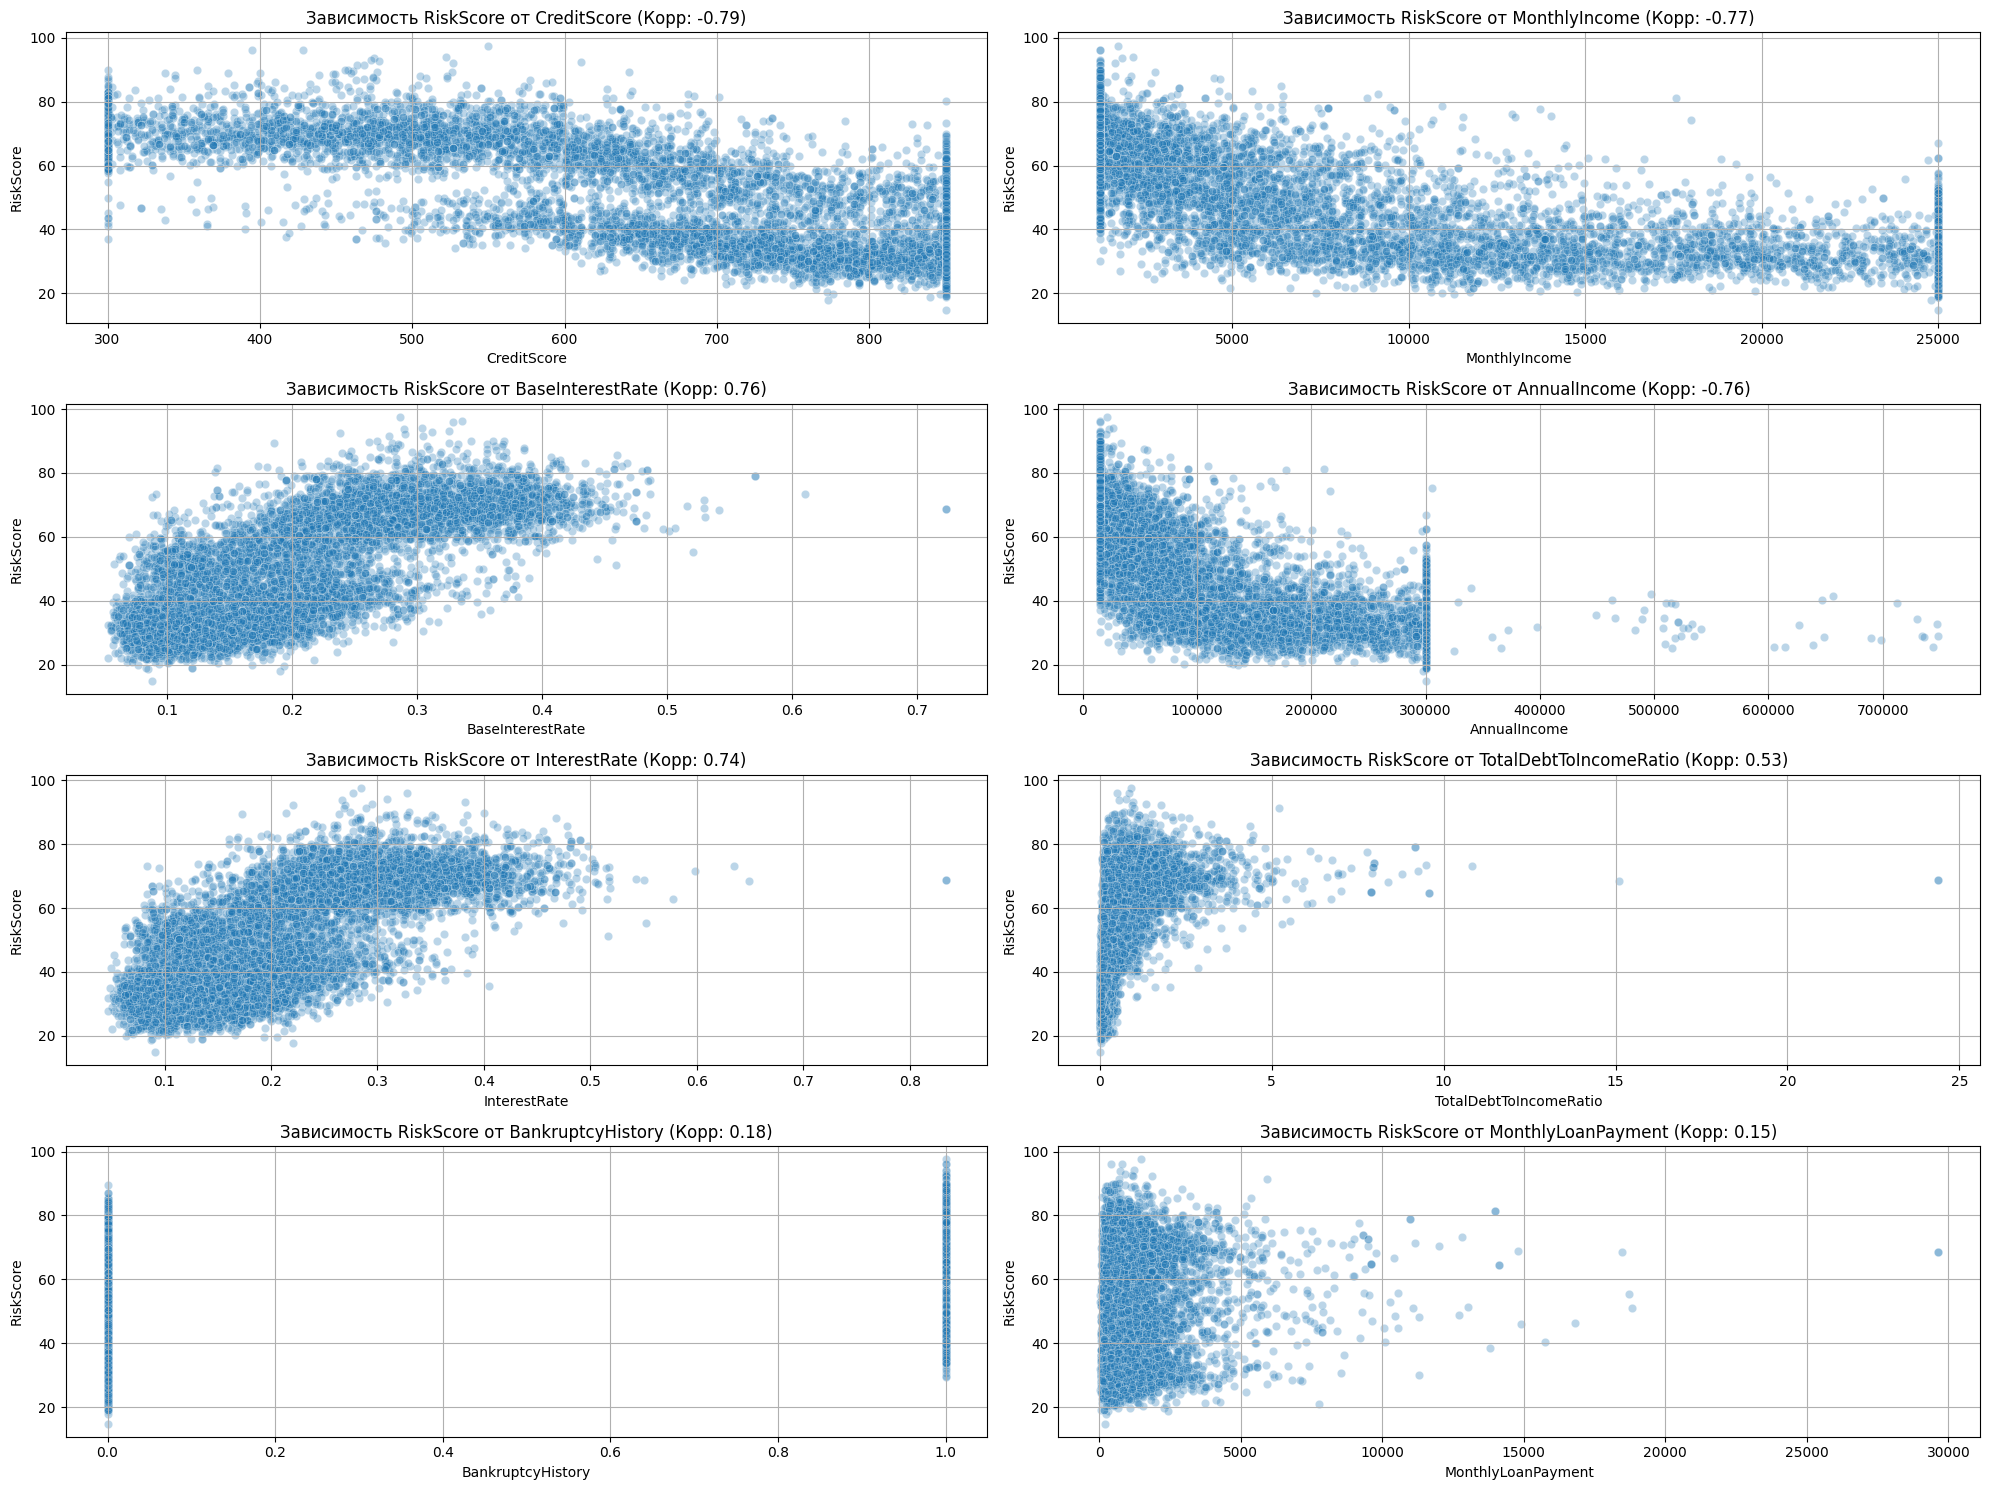

**Вывод:** Теперь мы видим тренды. CreditScore, MonthlyIncome и AnnualIncome демонстрируют сильную обратную зависимость: чем выше эти показатели, тем ниже оценка риска. BaseInterestRate и InterestRate показывают сильную прямую зависимость: чем выше ставка, тем выше риск.

**Топ-10 самых коррелирующих с RiskScore признаков (после очистки):**

,RiskScore
RiskScore,1.000000
BaseInterestRate,0.758712
InterestRate,0.742634
TotalDebtToIncomeRatio,0.530729
BankruptcyHistory,0.177559
MonthlyLoanPayment,0.150830
DebtToIncomeRatio,0.110862
LoanAmount,0.084978
CreditCardUtilizationRate,0.056063
PreviousLoanDefaults,0.054959


**Вывод:** Теперь мы видим более четко выраженные линейные зависимости. Интересно, что топ несколько изменился: теперь наиболее значимыми для предсказания RiskScore являются процентные ставки и общее соотношение долга к доходу.

In [6]:
# Задание №1: EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, Markdown # мне просто не нравится, что текст в print не выделяется

file_path = 'train.csv'

if os.path.exists(file_path):
    # общая инфа
    df = pd.read_csv(file_path)
    display(Markdown("**Взлетаем**"))
    display(Markdown("**Общая информация о датасете:**"))
    df.info()
    print()
    display(Markdown("**Верхушка этого айсберга:**"))
    display(df.head())

    # Целевая переменная график
    plt.figure(figsize=(15, 10))
    sns.histplot(df['RiskScore'], kde=True, bins=30)
    plt.title('Распределение RiskScore')
    plt.xlabel('RiskScore')
    plt.ylabel('Частота')
    plt.grid(True)
    plt.show()
    display(Markdown("**Вывод:** Небольшие выбросы в начале и конце, БОЛЬШИЕ около 0 и дальше все значения близки к 0. Как будто не очень, эти штуки будут вредить модельке"))
    display(df['RiskScore'].describe())
    display(Markdown("**Вывод:** Как будто это подтверждает идею о выбросах. Половина данных между 32 и 66, но есть экстремальные значения + среднее смещено"))


    # зависимости признаков друг от друга
    # мне кажется, что из 35 столбцов эти важны прямо
    signs = ['CreditScore', 'AnnualIncome', 'LoanAmount', 'DebtToIncomeRatio']
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(signs, 1):
        plt.subplot(2, 2, i)
        sns.scatterplot(x=df[feature], y=df['RiskScore'], alpha=0.5)
        plt.title(f'Зависимость RiskScore от {feature}')
        plt.xlabel(feature)
        plt.ylabel('RiskScore')
        plt.grid(True)

    plt.tight_layout()
    plt.show()
    display(Markdown("**Вывод:** Четкие горизонтальные линии. Как будто следствия этих выбросов. Реальную зависимость увидеть тяжко"))


    # матрица корреляции
    only_numerical_columns = df.select_dtypes(include=np.number)
    correlation_matrix = only_numerical_columns.corr()

    plt.figure(figsize=(20, 15))
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
    plt.title('Матрица корреляций')
    plt.show()

    display(Markdown("**Топ-10 самых коррелирующих с RiskScore признаков:**"))
    corr_with_target = correlation_matrix['RiskScore'].sort_values(ascending=False)
    display(corr_with_target.head(11))

    display(Markdown("**Вывод:** Тупые выбросы... Ну по топ-10 даже видно, что линейные зависимости почти не обнаруживаются. Лучшая корреляция у PaymentHistory, но и то мелкая"))


    # хочу графики зависимости между целевой переменной и значениями из топа
    corr_with_target_abs = correlation_matrix['RiskScore'].abs().sort_values(ascending=False)
    top_features = corr_with_target_abs[1:9].index

    plt.figure(figsize=(20, 15))
    for i, feature in enumerate(top_features, 1):
        plt.subplot(4, 2, i)
        sns.scatterplot(x=df[feature], y=df['RiskScore'], alpha=0.3)
        corr_coef = df[feature].corr(df['RiskScore'])
        plt.title(f'Зависимость RiskScore от {feature} (Корр: {corr_coef:.3f})')
        plt.grid(True)
    plt.tight_layout()
    plt.show()
    display(Markdown("**Вывод:** Результат ожидаемый..."))

    #добавим графики зависимостей переменных из топа между друг другом
    pairplot_features = top_features[:4]
    sns.pairplot(df[list(pairplot_features)])
    plt.suptitle('Матрица диаграмм рассеяния для топ-4 признаков', y=1.02)
    plt.show()
    display(Markdown("**Вывод:** Вроде они не коррелируют особо, значит мультиколлинеарность не беда."))

    display(Markdown("*Основная беда - экстремальные выбросы. Но мультиколлинеарности нет. Нужно очистить данные.*"))


    #Let`go чистить данные
    display(Markdown("## Очистка данных от выбросов"))

    lower_bound = -1_000_000
    upper_bound = 1_000_000

    df_cleaned = df[(df['RiskScore'] > lower_bound) & (df['RiskScore'] < upper_bound)].copy()

    original_rows = len(df)
    cleaned_rows = len(df_cleaned)
    display(Markdown(f"Исходное количество строк: `{original_rows}`."))
    display(Markdown(f"Количество строк после очистки: `{cleaned_rows}`."))
    display(Markdown(f"**Удалено `{original_rows - cleaned_rows}` строк с выбросами.**"))

    # Ну и снова посмотрим на то же самое

    display(Markdown("## Повторный взгляд на данные после очистки"))

    # 1. График целевой переменной
    display(Markdown("**1. Распределение `RiskScore` (очищенные данные):**"))
    plt.figure(figsize=(12, 6))
    sns.histplot(df_cleaned['RiskScore'], kde=True, bins=50)
    plt.title('Распределение RiskScore (очищенные данные)')
    plt.grid(True)
    plt.show()
    display(Markdown("**Вывод:** Теперь распределение выглядит как биномиальное: 1 вершина в районе возле 30, 2 - возле 70. МБ существует 2 скрытые категории клиентов, дальше разберемся"))

    # 2. Матрица корреляций
    display(Markdown("**2. Матрица корреляций (очищенные данные):**"))
    numeric_cols_cleaned = df_cleaned.select_dtypes(include=np.number)
    correlation_matrix_cleaned = numeric_cols_cleaned.corr()

    plt.figure(figsize=(20, 15))
    sns.heatmap(correlation_matrix_cleaned, annot=False, cmap='coolwarm')
    plt.title('Матрица корреляций (очищенные данные)')
    plt.show()
    display(Markdown("**Вывод:** Пятен стало больше (GOOD). Наиболее заметна сильная отрицательная корреляция RiskScore с CreditScore и MonthlyIncome (синие квадраты), и сильная положительная — с InterestRate и BaseInterestRate (красные квадраты)."))

    # 3. Графики зависимости Топ-признаков от RiskScore
    display(Markdown("**3. Зависимость Топ-8 признаков от `RiskScore` (очищенные данные):**"))
    corr_with_target_cleaned = correlation_matrix_cleaned['RiskScore'].abs().sort_values(ascending=False)
    top_features_cleaned = corr_with_target_cleaned[1:9].index

    plt.figure(figsize=(20, 15))
    for i, feature in enumerate(top_features_cleaned, 1):
        plt.subplot(4, 2, i)
        sns.scatterplot(x=df_cleaned[feature], y=df_cleaned['RiskScore'], alpha=0.3)
        corr_coef = df_cleaned[feature].corr(df_cleaned['RiskScore'])
        plt.title(f'Зависимость RiskScore от {feature} (Корр: {corr_coef:.2f})')
        plt.grid(True)

    plt.tight_layout()
    plt.show()
    display(Markdown("**Вывод:** Теперь мы видим тренды. CreditScore, MonthlyIncome и AnnualIncome демонстрируют сильную обратную зависимость: чем выше эти показатели, тем ниже оценка риска. BaseInterestRate и InterestRate показывают сильную прямую зависимость: чем выше ставка, тем выше риск."))

    display(Markdown("**Топ-10 самых коррелирующих с RiskScore признаков (после очистки):**"))
    corr_with_target_cleaned = correlation_matrix_cleaned['RiskScore'].sort_values(ascending=False)
    display(corr_with_target_cleaned.head(11))

    display(Markdown("**Вывод:** Теперь мы видим более четко выраженные линейные зависимости. Интересно, что топ несколько изменился: теперь наиболее значимыми для предсказания RiskScore являются процентные ставки и общее соотношение долга к доходу."))

else:
    display(Markdown(("**ЗАГРУЗИ файл пОжАлУйСта**")))

In [12]:
# Задание №2: Нормализация

# =============================================================================
# ЗАДАНИЕ №2 (Часть 2): Обработка пропусков и повторная нормализация
# =============================================================================

from IPython.display import display, Markdown
import pandas as pd
import numpy as np

try:
      # когда первый раз делал - увидел Nan -> есть пропуски -> нужно убрать их сперва
      display(Markdown("**Убираем пропуски в данных**"))
      df_imputed = df_cleaned.copy()
      numeric_cols = df_imputed.select_dtypes(include=np.number).columns
      for col in numeric_cols:
          median_val = df_imputed[col].median()
          df_imputed[col] = df_imputed[col].fillna(median_val)

      display(Markdown("**Делаем нормализацию**"))

      def z_score_scaler(data):
          mean = np.mean(data, axis=0)
          std = np.std(data, axis=0)
          epsilon = 1e-8
          return (data - mean) / (std + epsilon)

      def min_max_scaler(data):
          min_val = np.min(data, axis=0)
          max_val = np.max(data, axis=0)
          epsilon = 1e-8
          return (data - min_val) / (max_val - min_val + epsilon)

      # нам целевая переменная не нужна при нормализации
      numeric_features = df_imputed.select_dtypes(include=np.number)
      if 'RiskScore' in numeric_features.columns:
          numeric_features = numeric_features.drop('RiskScore', axis=1)
      numeric_feature_names = numeric_features.columns

      df_numeric_imputed = df_imputed[numeric_feature_names]

      # нормализуем
      df_z_scaled = pd.DataFrame(z_score_scaler(df_numeric_imputed.values), columns=numeric_feature_names)
      df_min_max_scaled = pd.DataFrame(min_max_scaler(df_numeric_imputed.values), columns=numeric_feature_names)

      display(Markdown("**Результат Z-score нормализации:**"))
      display(df_z_scaled.head())
      display(df_z_scaled.describe().loc[['mean', 'std']])

      display(Markdown("**Результат Min-Max нормализации:**"))
      display(df_min_max_scaled.head())
      display(df_min_max_scaled.describe().loc[['min', 'max']])

      display(Markdown("**Выводы по результатам нормализации:**"))
      display(Markdown("После z-score среднее значение для каждого признака можно сказать = 0, а стандартное отклонение = 1. Значит все корректно"))
      display(Markdown("После min-max нормализации min для каждого признака = 0, max = 1, следовательно мы масштабировали все данные в диапазон [0, 1]"))
      display(Markdown("Короче все круто, мы все нормализовали!"))
except Exception as e:
    print(f"Произошла ошибка: {e}")

**Убираем пропуски в данных**

**Делаем нормализацию**

**Результат Z-score нормализации:**

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,-1.108451,-0.558650,-0.764119,-0.450467,0.268131,-0.400573,1.130185,-0.831696,-0.591929,0.022255,...,-0.263579,-0.560983,1.005394,-0.432306,-1.203829,-0.249562,0.629564,0.530862,-0.421499,-0.256612
1,1.304533,0.350659,0.991696,-0.493848,-0.710632,-0.400573,-0.668116,-0.682975,-0.016743,-0.989281,...,-0.019743,0.373890,0.103462,-1.340227,1.355815,-0.267441,-1.228873,-1.108086,-0.417278,-0.520888
2,0.959821,1.454535,0.991696,0.326929,-0.710632,-1.105987,0.013367,1.003962,-0.016743,-0.989281,...,-0.268894,1.508799,1.067638,-0.886266,0.914497,0.289764,-0.987194,-0.877497,0.140186,-0.496417
3,-1.280807,-0.836197,0.974196,-0.380764,-0.221251,-1.105987,-0.786104,-0.602935,2.284003,-0.989281,...,-0.318138,-0.846332,0.746299,-0.886266,-1.556883,-0.306845,-1.071088,-0.904643,-0.429240,-0.326289
4,1.304533,1.454535,0.991696,0.032859,-0.221251,0.304842,0.045915,-0.069843,-0.016743,0.022255,...,1.382131,1.508799,0.846062,0.021655,1.179288,-0.317311,-0.965533,-1.150906,-0.238737,-0.518511


,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
mean,1.501049e-16,-8.784942e-17,-3.596984e-17,3.112775e-17,-1.182854e-16,-4.634576e-17,8.196974e-17,5.879686e-17,-1.151727e-16,-5.187958e-18,...,2.075183e-17,-5.118785e-17,8.636221e-16,-1.570222e-16,5.187958e-17,2.421047e-18,5.395476e-17,1.826161e-16,-8.093215e-17,6.917277e-18
std,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,...,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00


...

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Выводы по результатам нормализации:**

После z-score среднее значение для каждого признака можно сказать = 0, а стандартное отклонение = 1. Значит все корректно

После min-max нормализации min для каждого признака = 0, max = 1, следовательно мы масштабировали все данные в диапазон [0, 1]

Короче все круто, мы все нормализовали!